In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
from astropy import constants, units
import matplotlib.lines as mlines

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/'

In [3]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

Summary plots

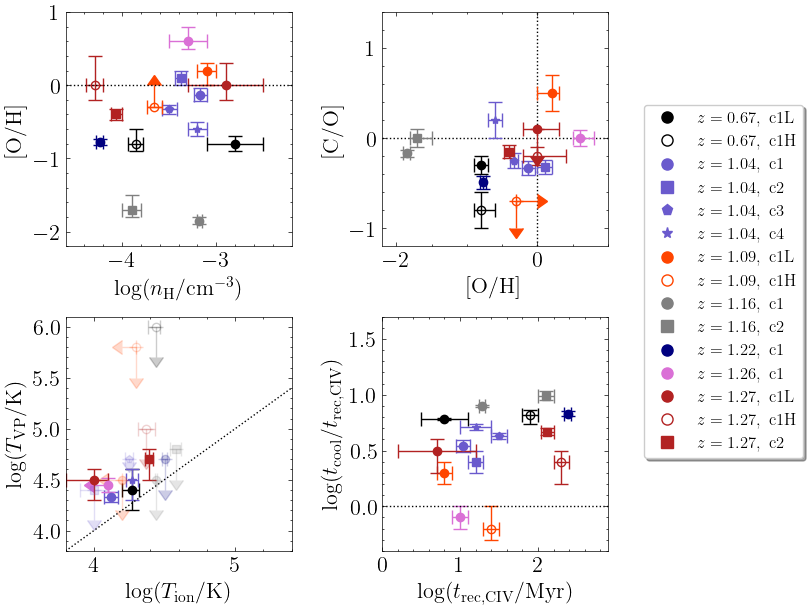

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(3.5*2, 3.5*2))

# n_H vs. metals
# z=0.67
axes[0,0].errorbar(-2.8, -0.8, xerr=0.3, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='black')

axes[0,0].errorbar(-3.85, -0.8, xerr=[[0.09],[0.07]], yerr=[[0.1],[0.2]], marker='o',
           linestyle='none', capsize=5, color='black', markerfacecolor='none')


# z=1.04
axes[0,0].errorbar(-3.17, -0.13, xerr=0.07, yerr=0.09, marker='o',
           linestyle='none', capsize=5, color='slateblue')

axes[0,0].errorbar(-3.38, 0.1, xerr=0.06, yerr=0.1, marker='s',
           linestyle='none', capsize=5, color='slateblue')

axes[0,0].errorbar(-3.50, -0.33, xerr=0.08, yerr=0.06, marker='p',
           linestyle='none', capsize=5, color='slateblue')

axes[0,0].errorbar(-3.2, -0.6, xerr=0.1, yerr=0.1, marker='*',
           linestyle='none', capsize=5, color='slateblue')


# z=1.09
axes[0,0].errorbar(-3.1, 0.2, xerr=0.1, yerr=[[0.2],[0.1]], marker='o',
           linestyle='none', capsize=5, color='orangered')

axes[0,0].errorbar(-3.66, -0.3, xerr=0.08, yerr=0.3, marker='o', lolims=True,
           linestyle='none', capsize=5, color='orangered', markerfacecolor='none')

# z=1.16
axes[0,0].errorbar(-3.18, -1.85, xerr=0.03, yerr=0.05, marker='o',
           linestyle='none', capsize=5, color='grey')

axes[0,0].errorbar(-3.9, -1.7, xerr=0.1, yerr=[[0.1],[0.2]], marker='s',
           linestyle='none', capsize=5, color='grey')

# z=1.22
axes[0,0].errorbar(-4.24, -0.77, xerr=0.04, yerr=0.04, marker='o',
           linestyle='none', capsize=5, color='navy')

# z=1.26
axes[0,0].errorbar(-3.3, 0.6, xerr=0.2, yerr=[[0.1],[0.2]], marker='o',
           linestyle='none', capsize=5, color='orchid')

# z=1.27
axes[0,0].errorbar(-2.9, 0.0, xerr=0.4, yerr=[[0.2],[0.3]], marker='o',
           linestyle='none', capsize=5, color='firebrick')

axes[0,0].errorbar(-4.29, 0.0, xerr=0.09, yerr=[[0.2],[0.4]], marker='o',
           linestyle='none', capsize=5, color='firebrick', markerfacecolor='none')

axes[0,0].errorbar(-4.06, -0.40, xerr=0.06, yerr=0.07, marker='s',
           linestyle='none', capsize=5, color='firebrick')

axes[0,0].axhline(0, linestyle=':')
axes[0,0].set_xlabel(r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})$')
axes[0,0].set_ylabel(r'$\mathrm{[O/H]}$')

axes[0,0].set_xlim(-4.6, -2.2)
axes[0,0].set_ylim(-2.2,1.0)

# metals vs. C_O
# z=0.67
axes[0,1].errorbar(-0.8, -0.3, xerr=0.1, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='black')

axes[0,1].errorbar(-0.8, -0.8, xerr=[[0.1],[0.2]], yerr=0.2, marker='o',
           linestyle='none', capsize=5, color='black', markerfacecolor='none')

axes[0,1].axvline(0, linestyle=':')
axes[0,1].axhline(0, linestyle=':')


# z=1.04
axes[0,1].errorbar(-0.13, -0.33, xerr=0.09, yerr=0.08, marker='o',
           linestyle='none', capsize=5, color='slateblue')

axes[0,1].errorbar(0.1, -0.32, xerr=0.1, yerr=0.08, marker='s',
           linestyle='none', capsize=5, color='slateblue')

axes[0,1].errorbar(-0.33, -0.25, xerr=0.06, yerr=0.08, marker='p',
           linestyle='none', capsize=5, color='slateblue')

axes[0,1].errorbar(-0.6, 0.2, xerr=0.1, yerr=0.2, marker='*',
           linestyle='none', capsize=5, color='slateblue')

# z=1.09
axes[0,1].errorbar(0.2, 0.5, xerr=[[0.2],[0.1]], yerr=0.2, marker='o',
           linestyle='none', capsize=5, color='orangered')

axes[0,1].errorbar(-0.3, -0.7, xerr=0.3, yerr=0.3, marker='o', xlolims=True,uplims=True,
           linestyle='none', capsize=5, color='orangered', markerfacecolor='none')

# z=1.16
axes[0,1].errorbar(-1.85, -0.17, xerr=0.05, yerr=0.04, marker='o',
           linestyle='none', capsize=5, color='grey')

axes[0,1].errorbar(-1.7, 0.0, xerr=[[0.1],[0.2]], yerr=0.1, marker='s',
           linestyle='none', capsize=5, color='grey')

# z=1.22
axes[0,1].errorbar(-0.77, -0.49, xerr=0.04, yerr=0.07, marker='o',
           linestyle='none', capsize=5, color='navy')

# z=1.26
axes[0,1].errorbar(0.6, 0.00, xerr=[[0.1],[0.2]], yerr=0.09, marker='o',
           linestyle='none', capsize=5, color='orchid')

# z=1.27
axes[0,1].errorbar(0.0, 0.1, xerr=[[0.2],[0.3]], yerr=0.3, marker='o', uplims=True,
           linestyle='none', capsize=5, color='firebrick')

axes[0,1].errorbar(0.0, -0.2, xerr=[[0.2],[0.4]], yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='firebrick', markerfacecolor='none')

axes[0,1].errorbar(-0.40, -0.15, xerr=0.07, yerr=0.07, marker='s',
           linestyle='none', capsize=5, color='firebrick')

axes[0,1].set_xlabel(r'$\mathrm{[O/H]}$')
axes[0,1].set_ylabel(r'$\mathrm{[C/O]}$')

axes[0,1].set_xlim(-2.2,1.0)
axes[0,1].set_ylim(-1.2, 1.4)

# logT_PIE, logT_VP

# z=0.67
axes[1,0].errorbar(4.27, 4.4, xerr=[[0.07], [0.05]], yerr=0.2, marker='o',
           linestyle='none', capsize=5, color='black')

axes[1,0].errorbar(4.44, 6.0, xerr=[[0.06],[0.03]], yerr=0.3, marker='o', uplims=True, alpha=.2,
           linestyle='none', capsize=5, color='black', markerfacecolor='none')

# z=1.04
axes[1,0].errorbar(4.12, 4.33, xerr=0.05, yerr=0.05, marker='o',
           linestyle='none', capsize=5, color='slateblue')

axes[1,0].errorbar(4.0, 4.4, xerr=0.1, yerr=0.3, marker='s', uplims=True,alpha=.2,
           linestyle='none', capsize=5, color='slateblue')

axes[1,0].errorbar(4.25, 4.7, xerr=0.03, yerr=0.03, marker='p', uplims=True,alpha=.2,
           linestyle='none', capsize=5, color='slateblue')

axes[1,0].errorbar(4.27, 4.5, xerr=0.04, yerr=[[0.2],[0.1]], marker='*',
           linestyle='none', capsize=5, color='slateblue')

# z=1.09
axes[1,0].errorbar(4.2, 4.5, xerr=0.1, yerr=0.3, marker='o', xuplims=True, uplims=True,alpha=.2,
           linestyle='none', capsize=5, color='orangered')

axes[1,0].errorbar(4.3, 5.8, xerr=0.1, yerr=0.3, marker='o', xuplims=True, uplims=True,alpha=.2,
           linestyle='none', capsize=5, color='orangered', markerfacecolor='none')

# z=1.16
axes[1,0].errorbar(4.44, 4.5, xerr=0.01, yerr=0.3, marker='o', uplims=True,alpha=.2,
           linestyle='none', capsize=5, color='grey')

axes[1,0].errorbar(4.58, 4.8, xerr=0.04, yerr=0.3, marker='s', uplims=True,alpha=.2,
           linestyle='none', capsize=5, color='grey')

# z=1.22
axes[1,0].errorbar(4.50, 4.7, xerr=0.02, yerr=0.3, marker='o', uplims=True,alpha=.2,
           linestyle='none', capsize=5, color='navy')

# z=1.26
axes[1,0].errorbar(4.1, 4.45, xerr=0.1, yerr=0.07, marker='o', xuplims=True,
           linestyle='none', capsize=5, color='orchid')

# z=1.27
axes[1,0].errorbar(4.0, 4.5, xerr=[[0.2],[0.1]], yerr=[[0.2],[0.1]], marker='o',
           linestyle='none', capsize=5, color='firebrick')

axes[1,0].errorbar(4.37, 5.0, xerr=0.06, yerr=0.3, marker='o', uplims=True,alpha=.2,
           linestyle='none', capsize=5, color='firebrick', markerfacecolor='none')

axes[1,0].errorbar(4.39, 4.7, xerr=0.03, yerr=[[0.2],[0.1]], marker='s',
           linestyle='none', capsize=5, color='firebrick')

t = np.arange(3.8,6.1)
axes[1,0].plot(t,t,linestyle=':')

axes[1,0].set_xlim(3.8,5.4)
axes[1,0].set_ylim(3.8,6.1)

axes[1,0].set_xlabel(r'$\log(T_\mathrm{ion}/\mathrm{K})$')
axes[1,0].set_ylabel(r'$\log(T_\mathrm{VP}/\mathrm{K})$')


# t_rec, t_cool
# z=0.67
axes[1,1].errorbar(0.8, 0.78, xerr=0.3, yerr=0.01, marker='o',
           linestyle='none', capsize=5, color='black')

axes[1,1].errorbar(1.9, 0.82, xerr=0.1, yerr=[[0.08],[0.04]], marker='o',
           linestyle='none', capsize=5, color='black', markerfacecolor='none')

# z=1.04
axes[1,1].errorbar(1.04, 0.54, xerr=0.09, yerr=0.05, marker='o',
           linestyle='none', capsize=5, color='slateblue')

axes[1,1].errorbar(1.2, 0.4, xerr=0.1, yerr=0.1, marker='s',
           linestyle='none', capsize=5, color='slateblue')

axes[1,1].errorbar(1.5, 0.63, xerr=0.1, yerr=0.03, marker='p',
           linestyle='none', capsize=5, color='slateblue')

axes[1,1].errorbar(1.2, 0.71, xerr=0.2, yerr=0.03, marker='*',
           linestyle='none', capsize=5, color='slateblue')

# z=1.09
axes[1,1].errorbar(0.8, 0.3, xerr=0.1, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='orangered')

axes[1,1].errorbar(1.4, -0.2, xerr=0.1, yerr=[[0.1],[0.2]], marker='o',
           linestyle='none', capsize=5, color='orangered', markerfacecolor='none')

# z=1.16
axes[1,1].errorbar(1.28, 0.90, xerr=0.04, yerr=0.01, marker='o',
           linestyle='none', capsize=5, color='grey')

axes[1,1].errorbar(2.1, 0.99, xerr=0.1, yerr=0.04, marker='s',
           linestyle='none', capsize=5, color='grey')

# z=1.22
axes[1,1].errorbar(2.38, 0.83, xerr=0.05, yerr=0.02, marker='o',
           linestyle='none', capsize=5, color='navy')

# z=1.26
axes[1,1].errorbar(1.0, -0.1, xerr=0.1, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='orchid')

# z=1.27
axes[1,1].errorbar(0.7, 0.5, xerr=0.5, yerr=[[0.2],[0.1]], marker='o',
           linestyle='none', capsize=5, color='firebrick')

axes[1,1].errorbar(2.3, 0.4, xerr=0.1, yerr=[[0.2],[0.1]], marker='o',
           linestyle='none', capsize=5, color='firebrick', markerfacecolor='none')

axes[1,1].errorbar(2.12, 0.67, xerr=0.08, yerr=0.03, marker='s',
           linestyle='none', capsize=5, color='firebrick')
axes[1,1].axhline(0, linestyle=':')

axes[1,1].set_xlabel(r'$\log(t_\mathrm{rec,CIV}/\mathrm{Myr})$')
axes[1,1].set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec,CIV})$')

axes[1,1].set_xlim(0,2.9)
axes[1,1].set_ylim(-0.4,1.7)

plt.subplots_adjust(wspace=0.4, hspace=0.3)

# Specify handles ONLY for this plot

handles = []
z_list = [r'$z=0.67,\ \mathrm{c1L}$', r'$z=0.67,\ \mathrm{c1H}$',
          r'$z=1.04,\ \mathrm{c1}$', r'$z=1.04,\ \mathrm{c2}$',
          r'$z=1.04,\ \mathrm{c3}$', r'$z=1.04,\ \mathrm{c4}$',
          r'$z=1.09,\ \mathrm{c1L}$', r'$z=1.09,\ \mathrm{c1H}$',
          r'$z=1.16,\ \mathrm{c1}$', r'$z=1.16,\ \mathrm{c2}$',
          r'$z=1.22,\ \mathrm{c1}$', r'$z=1.26,\ \mathrm{c1}$',
          r'$z=1.27,\ \mathrm{c1L}$', r'$z=1.27,\ \mathrm{c1H}$',
          r'$z=1.27,\ \mathrm{c2}$'
         ]

colors_list = ['black', 'black',
                 'slateblue', 'slateblue','slateblue','slateblue',
                 'orangered', 'orangered', 'grey', 'grey',
                 'navy', 'orchid',
                 'firebrick', 'firebrick', 'firebrick']

markers_list = ['o', 'o', 'o', 's', 'p', '*', 'o', 'o', 'o', 's', 'o', 'o', 'o' ,'o', 's']

fc_list = ['black', 'none',
                 'slateblue', 'slateblue','slateblue','slateblue',
                 'orangered', 'none', 'grey', 'grey',
                 'navy', 'orchid',
                 'firebrick', 'none', 'firebrick']

for i in range(len(z_list)):
    
    handles.append(mlines.Line2D([], [], color=colors_list[i], marker=markers_list[i],
                  markerfacecolor = fc_list[i],
                  linestyle='None', markersize=8, label=z_list[i]))
    
plt.legend(handles=handles, loc='center right', bbox_to_anchor=(1.9, 1.15),
          fancybox=True, shadow=True, ncol=1)

plt.savefig(rootdir+'Figures/PIE_summary.pdf', dpi=300)
plt.savefig(rootdir+'Figures/PIE_summary.png', dpi=300)

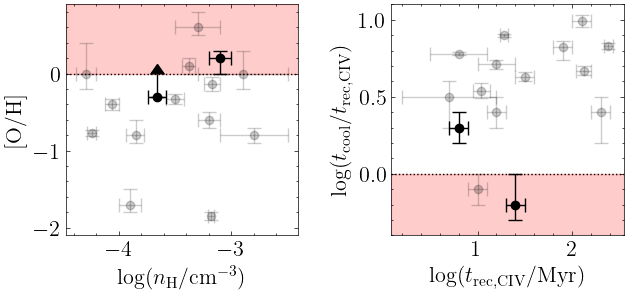

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(3.6*2, 3))

# n_H vs. metals
# z=0.67
# z=0.67
# n_H vs. metals
# z=0.67
axes[0].errorbar(-2.8, -0.8, xerr=0.3, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

axes[0].errorbar(-3.85, -0.8, xerr=[[0.09],[0.07]], yerr=[[0.1],[0.2]], marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)


# z=1.04
axes[0].errorbar(-3.17, -0.13, xerr=0.07, yerr=0.09, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

axes[0].errorbar(-3.38, 0.1, xerr=0.06, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

axes[0].errorbar(-3.50, -0.33, xerr=0.08, yerr=0.06, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

axes[0].errorbar(-3.2, -0.6, xerr=0.1, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)


# z=1.09
axes[0].errorbar(-3.1, 0.2, xerr=0.1, yerr=[[0.2],[0.1]], marker='o',
           linestyle='none', capsize=5, color='black')

axes[0].errorbar(-3.66, -0.3, xerr=0.08, yerr=0.3, marker='o', lolims=True,
           linestyle='none', capsize=5, color='black')

# z=1.16
axes[0].errorbar(-3.18, -1.85, xerr=0.03, yerr=0.05, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

axes[0].errorbar(-3.9, -1.7, xerr=0.1, yerr=[[0.1],[0.2]], marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

# z=1.22
axes[0].errorbar(-4.24, -0.77, xerr=0.04, yerr=0.04, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

# z=1.26
axes[0].errorbar(-3.3, 0.6, xerr=0.2, yerr=[[0.1],[0.2]], marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

# z=1.27
axes[0].errorbar(-2.9, 0.0, xerr=0.4, yerr=[[0.2],[0.3]], marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

axes[0].errorbar(-4.29, 0.0, xerr=0.09, yerr=[[0.2],[0.4]], marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

axes[0].errorbar(-4.06, -0.40, xerr=0.06, yerr=0.07, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)


axes[0].axhline(0, linestyle=':')
axes[0].set_xlabel(r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})$')
axes[0].set_ylabel(r'$\mathrm{[O/H]}$')

axes[0].axhspan(0,0.9,color='red',alpha=.2)
#axes[0].axhspan(-2.1,-1.0,color='green',alpha=.2)

#axes[0].set_xlim(-4.8, -2.0)
axes[0].set_ylim(-2.1,0.9)

# t_rec, t_cool
# z=0.67
axes[1].errorbar(0.8, 0.78, xerr=0.3, yerr=0.01, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

axes[1].errorbar(1.9, 0.82, xerr=0.1, yerr=[[0.08],[0.04]], marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

# z=1.04
axes[1].errorbar(1.04, 0.54, xerr=0.09, yerr=0.05, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

axes[1].errorbar(1.2, 0.4, xerr=0.1, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

axes[1].errorbar(1.5, 0.63, xerr=0.1, yerr=0.03, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

axes[1].errorbar(1.2, 0.71, xerr=0.2, yerr=0.03, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

# z=1.09
axes[1].errorbar(0.8, 0.3, xerr=0.1, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='black')

axes[1].errorbar(1.4, -0.2, xerr=0.1, yerr=[[0.1],[0.2]], marker='o',
           linestyle='none', capsize=5, color='black')

# z=1.16
axes[1].errorbar(1.28, 0.90, xerr=0.04, yerr=0.01, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

axes[1].errorbar(2.1, 0.99, xerr=0.1, yerr=0.04, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

# z=1.22
axes[1].errorbar(2.38, 0.83, xerr=0.05, yerr=0.02, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

# z=1.26
axes[1].errorbar(1.0, -0.1, xerr=0.1, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

# z=1.27
axes[1].errorbar(0.7, 0.5, xerr=0.5, yerr=[[0.2],[0.1]], marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

axes[1].errorbar(2.3, 0.4, xerr=0.1, yerr=[[0.2],[0.1]], marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)

axes[1].errorbar(2.12, 0.67, xerr=0.08, yerr=0.03, marker='o',
           linestyle='none', capsize=5, color='black', alpha=.2)
axes[1].axhline(0, linestyle=':')

axes[1].axhspan(-0.4,0.0,color='red',alpha=.2)

axes[1].set_ylim(-0.4,1.1)

plt.subplots_adjust(wspace=0.4, hspace=0.0)

axes[1].set_xlabel(r'$\log(t_\mathrm{rec,CIV}/\mathrm{Myr})$')
axes[1].set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec,CIV})$')

# Specify handles ONLY for this plot

handles = []
z_list = [r'$z=0.67,\ \mathrm{c1L}$', r'$z=0.67,\ \mathrm{c1H}$',
          r'$z=1.04,\ \mathrm{c1}$', r'$z=1.04,\ \mathrm{c2}$',
          r'$z=1.04,\ \mathrm{c3}$', r'$z=1.04,\ \mathrm{c4}$',
          r'$z=1.09,\ \mathrm{c1L}$', r'$z=1.09,\ \mathrm{c1H}$',
          r'$z=1.16,\ \mathrm{c1}$', r'$z=1.16,\ \mathrm{c2}$',
          r'$z=1.22,\ \mathrm{c1}$', r'$z=1.26,\ \mathrm{c1}$',
          r'$z=1.27,\ \mathrm{c1L}$', r'$z=1.27,\ \mathrm{c1H}$',
          r'$z=1.27,\ \mathrm{c2}$'
         ]

colors_list = ['black', 'black',
                 'slateblue', 'slateblue','slateblue','slateblue',
                 'orangered', 'orangered', 'grey', 'grey',
                 'navy', 'orchid',
                 'firebrick', 'firebrick', 'firebrick']

markers_list = ['o', 'o', 'o', 's', 'v', '*', 'o', 'o', 'o', 's', 'o', 'o', 'o' ,'o', 's']

fc_list = ['black', 'none',
                 'slateblue', 'slateblue','slateblue','slateblue',
                 'orangered', 'none', 'grey', 'grey',
                 'navy', 'orchid',
                 'firebrick', 'none', 'firebrick']

for i in range(len(z_list)):
    
    handles.append(mlines.Line2D([], [], color=colors_list[i], marker=markers_list[i],
                  markerfacecolor = fc_list[i],
                  linestyle='None', markersize=8, label=z_list[i]))
    
#plt.legend(handles=handles, loc='upper center', bbox_to_anchor=(-0.93, 1.5),
#          fancybox=True, shadow=True, ncol=5)

plt.savefig(rootdir+'Figures/PIE_summary_slides.pdf', dpi=300)
plt.savefig(rootdir+'Figures/PIE_summary_slides.png', dpi=300)

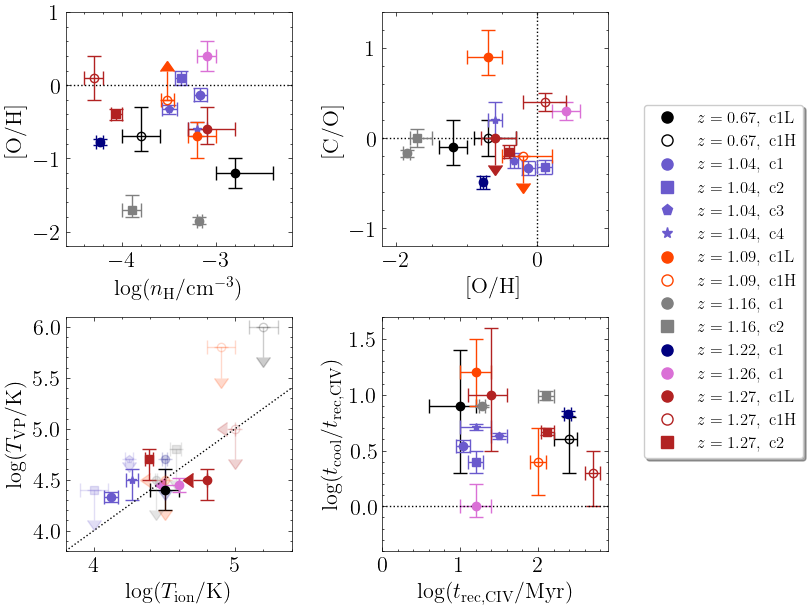

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(3.5*2, 3.5*2))

# n_H vs. metals
# z=0.67
axes[0,0].errorbar(-2.8, -1.2, xerr=[[0.2],[0.4]], yerr=0.2, marker='o',
           linestyle='none', capsize=5, color='black')

axes[0,0].errorbar(-3.8, -0.7, xerr=0.2, yerr=[[0.2],[0.4]], marker='o',
           linestyle='none', capsize=5, color='black', markerfacecolor='none')


# z=1.04
axes[0,0].errorbar(-3.17, -0.13, xerr=0.07, yerr=0.09, marker='o',
           linestyle='none', capsize=5, color='slateblue')

axes[0,0].errorbar(-3.38, 0.1, xerr=0.06, yerr=0.1, marker='s',
           linestyle='none', capsize=5, color='slateblue')

axes[0,0].errorbar(-3.50, -0.33, xerr=0.08, yerr=0.06, marker='p',
           linestyle='none', capsize=5, color='slateblue')

axes[0,0].errorbar(-3.2, -0.6, xerr=0.1, yerr=0.1, marker='*',
           linestyle='none', capsize=5, color='slateblue')


# z=1.09
axes[0,0].errorbar(-3.2, -0.7, xerr=[[0.1],[0.2]], yerr=[[0.3],[0.2]], marker='o',
           linestyle='none', capsize=5, color='orangered')

axes[0,0].errorbar(-3.52, -0.2, xerr=0.07, yerr=[[0.3],[0.4]], marker='o', lolims=True,
           linestyle='none', capsize=5, color='orangered', markerfacecolor='none')

# z=1.16
axes[0,0].errorbar(-3.18, -1.85, xerr=0.03, yerr=0.05, marker='o',
           linestyle='none', capsize=5, color='grey')

axes[0,0].errorbar(-3.9, -1.7, xerr=0.1, yerr=[[0.1],[0.2]], marker='s',
           linestyle='none', capsize=5, color='grey')

# z=1.22
axes[0,0].errorbar(-4.24, -0.77, xerr=0.04, yerr=0.04, marker='o',
           linestyle='none', capsize=5, color='navy')

# z=1.26
axes[0,0].errorbar(-3.1, 0.4, xerr=0.1, yerr=0.2, marker='o',
           linestyle='none', capsize=5, color='orchid')

# z=1.27
axes[0,0].errorbar(-3.1, -0.6, xerr=[[0.2],[0.3]], yerr=[[0.2],[0.3]], marker='o',
           linestyle='none', capsize=5, color='firebrick')

axes[0,0].errorbar(-4.3, 0.1, xerr=0.1, yerr=0.3, marker='o',
           linestyle='none', capsize=5, color='firebrick', markerfacecolor='none')

axes[0,0].errorbar(-4.06, -0.40, xerr=0.06, yerr=0.07, marker='s',
           linestyle='none', capsize=5, color='firebrick')

axes[0,0].axhline(0, linestyle=':')
axes[0,0].set_xlabel(r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})$')
axes[0,0].set_ylabel(r'$\mathrm{[O/H]}$')

axes[0,0].set_xlim(-4.6, -2.2)
axes[0,0].set_ylim(-2.2,1.0)

# metals vs. C_O
# z=0.67
axes[0,1].errorbar(-1.2, -0.1, xerr=0.2, yerr=[[0.2],[0.3]], marker='o',
           linestyle='none', capsize=5, color='black')

axes[0,1].errorbar(-0.7, 0.0, xerr=[[0.2],[0.4]], yerr=0.2, marker='o',
           linestyle='none', capsize=5, color='black', markerfacecolor='none')

axes[0,1].axvline(0, linestyle=':')
axes[0,1].axhline(0, linestyle=':')


# z=1.04
axes[0,1].errorbar(-0.13, -0.33, xerr=0.09, yerr=0.08, marker='o',
           linestyle='none', capsize=5, color='slateblue')

axes[0,1].errorbar(0.1, -0.32, xerr=0.1, yerr=0.08, marker='s',
           linestyle='none', capsize=5, color='slateblue')

axes[0,1].errorbar(-0.33, -0.25, xerr=0.06, yerr=0.08, marker='p',
           linestyle='none', capsize=5, color='slateblue')

axes[0,1].errorbar(-0.6, 0.2, xerr=0.1, yerr=0.2, marker='*',
           linestyle='none', capsize=5, color='slateblue')

# z=1.09
axes[0,1].errorbar(-0.7, 0.9, xerr=[[0.3],[0.2]], yerr=[[0.2],[0.3]], marker='o',
           linestyle='none', capsize=5, color='orangered')

axes[0,1].errorbar(-0.2, -0.2, xerr=[[0.3],[0.4]], yerr=0.3, marker='o', uplims=True,
           linestyle='none', capsize=5, color='orangered', markerfacecolor='none')

# z=1.16
axes[0,1].errorbar(-1.85, -0.17, xerr=0.05, yerr=0.04, marker='o',
           linestyle='none', capsize=5, color='grey')

axes[0,1].errorbar(-1.7, 0.0, xerr=[[0.1],[0.2]], yerr=0.1, marker='s',
           linestyle='none', capsize=5, color='grey')

# z=1.22
axes[0,1].errorbar(-0.77, -0.49, xerr=0.04, yerr=0.07, marker='o',
           linestyle='none', capsize=5, color='navy')

# z=1.26
axes[0,1].errorbar(0.4, 0.3, xerr=0.2, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='orchid')

# z=1.27
axes[0,1].errorbar(-0.6, 0.0, xerr=[[0.2],[0.3]], yerr=0.3, marker='o', uplims=True,
           linestyle='none', capsize=5, color='firebrick')

axes[0,1].errorbar(0.1, 0.4, xerr=0.3, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='firebrick', markerfacecolor='none')

axes[0,1].errorbar(-0.40, -0.15, xerr=0.07, yerr=0.07, marker='s',
           linestyle='none', capsize=5, color='firebrick')

axes[0,1].set_xlabel(r'$\mathrm{[O/H]}$')
axes[0,1].set_ylabel(r'$\mathrm{[C/O]}$')

axes[0,1].set_xlim(-2.2,1.0)
axes[0,1].set_ylim(-1.2, 1.4)

# logT_PIE, logT_VP

# z=0.67
axes[1,0].errorbar(4.5, 4.4, xerr=0.1, yerr=0.2, marker='o',
           linestyle='none', capsize=5, color='black')

axes[1,0].errorbar(5.2, 6.0, xerr=0.1, yerr=0.3, marker='o', uplims=True, alpha=.2,
           linestyle='none', capsize=5, color='black', markerfacecolor='none')

# z=1.04
axes[1,0].errorbar(4.12, 4.33, xerr=0.05, yerr=0.05, marker='o',
           linestyle='none', capsize=5, color='slateblue')

axes[1,0].errorbar(4.0, 4.4, xerr=0.1, yerr=0.3, marker='s', uplims=True,alpha=.2,
           linestyle='none', capsize=5, color='slateblue')

axes[1,0].errorbar(4.25, 4.7, xerr=0.03, yerr=0.03, marker='p', uplims=True,alpha=.2,
           linestyle='none', capsize=5, color='slateblue')

axes[1,0].errorbar(4.27, 4.5, xerr=0.04, yerr=[[0.2],[0.1]], marker='*',
           linestyle='none', capsize=5, color='slateblue')

# z=1.09
axes[1,0].errorbar(4.5, 4.5, xerr=0.1, yerr=0.3, marker='o', xuplims=True, uplims=True,alpha=.2,
           linestyle='none', capsize=5, color='orangered')

axes[1,0].errorbar(4.9, 5.8, xerr=0.1, yerr=0.3, marker='o', uplims=True,alpha=.2,
           linestyle='none', capsize=5, color='orangered', markerfacecolor='none')

# z=1.16
axes[1,0].errorbar(4.44, 4.5, xerr=0.01, yerr=0.3, marker='o', uplims=True,alpha=.2,
           linestyle='none', capsize=5, color='grey')

axes[1,0].errorbar(4.58, 4.8, xerr=0.04, yerr=0.3, marker='s', uplims=True,alpha=.2,
           linestyle='none', capsize=5, color='grey')

# z=1.22
axes[1,0].errorbar(4.50, 4.7, xerr=0.02, yerr=0.3, marker='o', uplims=True,alpha=.2,
           linestyle='none', capsize=5, color='navy')

# z=1.26
axes[1,0].errorbar(4.6, 4.45, xerr=0.1, yerr=0.07, marker='o', xuplims=True,
           linestyle='none', capsize=5, color='orchid')

# z=1.27
axes[1,0].errorbar(4.8, 4.5, xerr=0.1, yerr=[[0.2],[0.1]], marker='o', xuplims=True,
           linestyle='none', capsize=5, color='firebrick')

axes[1,0].errorbar(5.0, 5.0, xerr=0.06, yerr=0.3, marker='o', xuplims=True, uplims=True,alpha=.2,
           linestyle='none', capsize=5, color='firebrick', markerfacecolor='none')

axes[1,0].errorbar(4.39, 4.7, xerr=0.03, yerr=[[0.2],[0.1]], marker='s',
           linestyle='none', capsize=5, color='firebrick')

t = np.arange(3.8,6.1)
axes[1,0].plot(t,t,linestyle=':')

axes[1,0].set_xlim(3.8,5.4)
axes[1,0].set_ylim(3.8,6.1)

axes[1,0].set_xlabel(r'$\log(T_\mathrm{ion}/\mathrm{K})$')
axes[1,0].set_ylabel(r'$\log(T_\mathrm{VP}/\mathrm{K})$')


# t_rec, t_cool
# z=0.67
axes[1,1].errorbar(1.0, 0.9, xerr=[[0.4],[0.2]], yerr=[[0.6],[0.5]], marker='o',
           linestyle='none', capsize=5, color='black')

axes[1,1].errorbar(2.4, 0.6, xerr=[[0.2],[0.1]], yerr=[[0.3],[0.2]], marker='o',
           linestyle='none', capsize=5, color='black', markerfacecolor='none')

# z=1.04
axes[1,1].errorbar(1.04, 0.54, xerr=0.09, yerr=0.05, marker='o',
           linestyle='none', capsize=5, color='slateblue')

axes[1,1].errorbar(1.2, 0.4, xerr=0.1, yerr=0.1, marker='s',
           linestyle='none', capsize=5, color='slateblue')

axes[1,1].errorbar(1.5, 0.63, xerr=0.1, yerr=0.03, marker='p',
           linestyle='none', capsize=5, color='slateblue')

axes[1,1].errorbar(1.2, 0.71, xerr=0.2, yerr=0.03, marker='*',
           linestyle='none', capsize=5, color='slateblue')

# z=1.09
axes[1,1].errorbar(1.2, 1.2, xerr=0.2, yerr=0.3, marker='o',
           linestyle='none', capsize=5, color='orangered')

axes[1,1].errorbar(2.0, 0.4, xerr=0.1, yerr=0.3, marker='o',
           linestyle='none', capsize=5, color='orangered', markerfacecolor='none')

# z=1.16
axes[1,1].errorbar(1.28, 0.90, xerr=0.04, yerr=0.01, marker='o',
           linestyle='none', capsize=5, color='grey')

axes[1,1].errorbar(2.1, 0.99, xerr=0.1, yerr=0.04, marker='s',
           linestyle='none', capsize=5, color='grey')

# z=1.22
axes[1,1].errorbar(2.38, 0.83, xerr=0.05, yerr=0.02, marker='o',
           linestyle='none', capsize=5, color='navy')

# z=1.26
axes[1,1].errorbar(1.2, 0.0, xerr=0.2, yerr=[[0.1],[0.2]], marker='o',
           linestyle='none', capsize=5, color='orchid')

# z=1.27
axes[1,1].errorbar(1.4, 1.0, xerr=[[0.3],[0.2]], yerr=[[0.5],[0.6]], marker='o',
           linestyle='none', capsize=5, color='firebrick')

axes[1,1].errorbar(2.7, 0.3, xerr=0.1, yerr=[[0.3],[0.2]], marker='o',
           linestyle='none', capsize=5, color='firebrick', markerfacecolor='none')

axes[1,1].errorbar(2.12, 0.67, xerr=0.08, yerr=0.03, marker='s',
           linestyle='none', capsize=5, color='firebrick')
axes[1,1].axhline(0, linestyle=':')

axes[1,1].set_xlabel(r'$\log(t_\mathrm{rec,CIV}/\mathrm{Myr})$')
axes[1,1].set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec,CIV})$')

axes[1,1].set_xlim(0,2.9)
axes[1,1].set_ylim(-0.4,1.7)

plt.subplots_adjust(wspace=0.4, hspace=0.3)

# Specify handles ONLY for this plot

handles = []
z_list = [r'$z=0.67,\ \mathrm{c1L}$', r'$z=0.67,\ \mathrm{c1H}$',
          r'$z=1.04,\ \mathrm{c1}$', r'$z=1.04,\ \mathrm{c2}$',
          r'$z=1.04,\ \mathrm{c3}$', r'$z=1.04,\ \mathrm{c4}$',
          r'$z=1.09,\ \mathrm{c1L}$', r'$z=1.09,\ \mathrm{c1H}$',
          r'$z=1.16,\ \mathrm{c1}$', r'$z=1.16,\ \mathrm{c2}$',
          r'$z=1.22,\ \mathrm{c1}$', r'$z=1.26,\ \mathrm{c1}$',
          r'$z=1.27,\ \mathrm{c1L}$', r'$z=1.27,\ \mathrm{c1H}$',
          r'$z=1.27,\ \mathrm{c2}$'
         ]

colors_list = ['black', 'black',
                 'slateblue', 'slateblue','slateblue','slateblue',
                 'orangered', 'orangered', 'grey', 'grey',
                 'navy', 'orchid',
                 'firebrick', 'firebrick', 'firebrick']

markers_list = ['o', 'o', 'o', 's', 'p', '*', 'o', 'o', 'o', 's', 'o', 'o', 'o' ,'o', 's']

fc_list = ['black', 'none',
                 'slateblue', 'slateblue','slateblue','slateblue',
                 'orangered', 'none', 'grey', 'grey',
                 'navy', 'orchid',
                 'firebrick', 'none', 'firebrick']

for i in range(len(z_list)):
    
    handles.append(mlines.Line2D([], [], color=colors_list[i], marker=markers_list[i],
                  markerfacecolor = fc_list[i],
                  linestyle='None', markersize=8, label=z_list[i]))
    
plt.legend(handles=handles, loc='center right', bbox_to_anchor=(1.9, 1.15),
          fancybox=True, shadow=True, ncol=1)

plt.savefig(rootdir+'Figures/TDP_summary.pdf', dpi=300)
plt.savefig(rootdir+'Figures/TDP_summary.png', dpi=300)

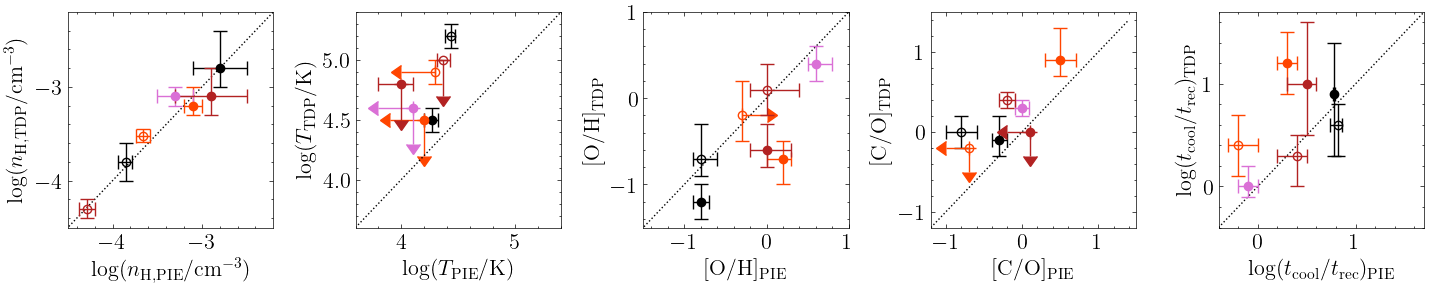

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(3.5*5, 2.8*1))

# n_H
# z=0.67

x = np.arange(-5,-2.0,0.1)
axes[0].plot(x,x,linestyle=':')

axes[0].errorbar(-2.8, -2.8, xerr=0.3, yerr=[[0.2],[0.4]], marker='o',
           linestyle='none', capsize=5, color='black')

axes[0].errorbar(-3.85, -3.8, xerr=[[0.09],[0.07]], yerr=0.2, marker='o',
           linestyle='none', capsize=5, color='black', markerfacecolor='none')


# z=1.09
axes[0].errorbar(-3.1, -3.2, xerr=0.1, yerr=[[0.1],[0.2]], marker='o',
           linestyle='none', capsize=5, color='orangered')

axes[0].errorbar(-3.66, -3.52, xerr=0.08, yerr=0.07, marker='o',
           linestyle='none', capsize=5, color='orangered', markerfacecolor='none')

# z=1.26
axes[0].errorbar(-3.3, -3.1, xerr=0.2, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='orchid')

# z=1.27
axes[0].errorbar(-2.9, -3.1, xerr=0.4, yerr=[[0.2],[0.3]], marker='o',
           linestyle='none', capsize=5, color='firebrick')

axes[0].errorbar(-4.29, -4.3, xerr=0.09, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='firebrick', markerfacecolor='none')

axes[0].set_xlabel(r'$\log(n_\mathrm{H,PIE}/\mathrm{cm}^{-3})$')
axes[0].set_ylabel(r'$\log(n_\mathrm{H,TDP}/\mathrm{cm}^{-3})$')

axes[0].set_xlim(-4.5, -2.2)
axes[0].set_ylim(-4.5, -2.2)

# logT

# z=0.67
axes[1].errorbar(4.27, 4.5, xerr=[[0.07],[0.05]], yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='black')

axes[1].errorbar(4.44, 5.2, xerr=[[0.06],[0.03]], yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='black', markerfacecolor='none')

# z=1.09
axes[1].errorbar(4.2, 4.5, xerr=0.3, yerr=0.3, marker='o', xuplims=True, uplims=True,
           linestyle='none', capsize=5, color='orangered')

axes[1].errorbar(4.3, 4.9, xerr=0.3, yerr=0.1, marker='o', xuplims=True, 
           linestyle='none', capsize=5, color='orangered', markerfacecolor='none')

# z=1.26
axes[1].errorbar(4.1, 4.6, xerr=0.3, yerr=0.3, marker='o', xuplims=True, uplims=True,
           linestyle='none', capsize=5, color='orchid')

# z=1.27
axes[1].errorbar(4.0, 4.8, xerr=[[0.2],[0.1]], yerr=0.3, marker='o', uplims=True,
           linestyle='none', capsize=5, color='firebrick')

axes[1].errorbar(4.37, 5.0, xerr=0.06, yerr=0.3, marker='o', uplims=True,
           linestyle='none', capsize=5, color='firebrick', markerfacecolor='none')

t = np.arange(3.6,5.6,0.1)
axes[1].plot(t,t,linestyle=':')

axes[1].set_xlim(3.6,5.4)
axes[1].set_ylim(3.6,5.4)

axes[1].set_xlabel(r'$\log(T_\mathrm{PIE}/\mathrm{K})$')
axes[1].set_ylabel(r'$\log(T_\mathrm{TDP}/\mathrm{K})$')

# metals

x = np.arange(-3,1.2,0.1)
axes[2].plot(x,x,linestyle=':')

# z=0.67
axes[2].errorbar(-0.8, -1.2, xerr=0.1, yerr=0.2, marker='o',
           linestyle='none', capsize=5, color='black')

axes[2].errorbar(-0.8, -0.7, xerr=[[0.1],[0.2]], yerr=[[0.2],[0.4]], marker='o',
           linestyle='none', capsize=5, color='black', markerfacecolor='none')

# z=1.09
axes[2].errorbar(0.2, -0.7, xerr=[[0.2],[0.1]], yerr=[[0.3],[0.2]], marker='o',
           linestyle='none', capsize=5, color='orangered')

axes[2].errorbar(-0.3, -0.2, xerr=0.3, yerr=[[0.3],[0.4]], marker='o', xlolims=True,
           linestyle='none', capsize=5, color='orangered', markerfacecolor='none')

# z=1.26
axes[2].errorbar(0.6, 0.4, xerr=[[0.1],[0.2]], yerr=0.2, marker='o',
           linestyle='none', capsize=5, color='orchid')

# z=1.27
axes[2].errorbar(0.0, -0.6, xerr=[[0.2],[0.3]], yerr=[[0.2],[0.3]], marker='o',
           linestyle='none', capsize=5, color='firebrick')

axes[2].errorbar(0.0, 0.1, xerr=[[0.2],[0.4]], yerr=0.3, marker='o',
           linestyle='none', capsize=5, color='firebrick', markerfacecolor='none')

axes[2].set_xlabel(r'$\mathrm{[O/H]_{PIE}}$')
axes[2].set_ylabel(r'$\mathrm{[O/H]_{TDP}}$')

axes[2].set_xlim(-1.5, 1.0)
axes[2].set_ylim(-1.5, 1.0)

# C/O

x = np.arange(-1.3,1.5,0.1)
axes[3].plot(x,x,linestyle=':')

# z=0.67
axes[3].errorbar(-0.3, -0.1, xerr=0.1, yerr=[[0.2],[0.3]], marker='o',
           linestyle='none', capsize=5, color='black')

axes[3].errorbar(-0.8, 0.0, xerr=0.2, yerr=0.2, marker='o',
           linestyle='none', capsize=5, color='black', markerfacecolor='none')

# z=1.09
axes[3].errorbar(0.5, 0.9, xerr=0.2, yerr=[[0.2],[0.4]], marker='o',
           linestyle='none', capsize=5, color='orangered')

axes[3].errorbar(-0.7, -0.2, xerr=0.3, yerr=0.3, marker='o', xuplims=True,uplims=True,
           linestyle='none', capsize=5, color='orangered', markerfacecolor='none')

# z=1.26
axes[3].errorbar(0.00, 0.3, xerr=0.09, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='orchid')

# z=1.27
axes[3].errorbar(0.1, 0.0, xerr=0.3, yerr=0.3, marker='o', xuplims=True, uplims=True,
           linestyle='none', capsize=5, color='firebrick')

axes[3].errorbar(-0.2, 0.4, xerr=0.1, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='firebrick', markerfacecolor='none')

axes[3].set_xlabel(r'$\mathrm{[C/O]_{PIE}}$')
axes[3].set_ylabel(r'$\mathrm{[C/O]_{TDP}}$')

axes[3].set_xlim(-1.2, 1.5)
axes[3].set_ylim(-1.2, 1.5)

# t_cool/t_rec

x = np.arange(-0.4,1.8,0.1)
axes[4].plot(x,x,linestyle=':')

# z=0.67
axes[4].errorbar(0.78, 0.9, xerr=0.01, yerr=[[0.6],[0.5]], marker='o',
           linestyle='none', capsize=5, color='black')

axes[4].errorbar(0.82, 0.6, xerr=[[0.08],[0.04]], yerr=[[0.3],[0.2]], marker='o',
           linestyle='none', capsize=5, color='black', markerfacecolor='none')

# z=1.09
axes[4].errorbar(0.3, 1.2, xerr=0.1, yerr=0.3, marker='o',
           linestyle='none', capsize=5, color='orangered')

axes[4].errorbar(-0.2, 0.4, xerr=[[0.1],[0.2]], yerr=0.3, marker='o',
           linestyle='none', capsize=5, color='orangered', markerfacecolor='none')

# z=1.26
axes[4].errorbar(-0.1, 0.0, xerr=0.1, yerr=[[0.1],[0.2]], marker='o',
           linestyle='none', capsize=5, color='orchid')

# z=1.27
axes[4].errorbar(0.5, 1.0, xerr=[[0.2],[0.1]], yerr=[[0.5],[0.6]], marker='o',
           linestyle='none', capsize=5, color='firebrick')

axes[4].errorbar(0.4, 0.3, xerr=[[0.2],[0.1]], yerr=[[0.3],[0.2]], marker='o',
           linestyle='none', capsize=5, color='firebrick', markerfacecolor='none')

axes[4].set_xlabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec})_\mathrm{PIE}$')
axes[4].set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec})_\mathrm{TDP}$')

axes[4].set_xlim(-0.4, 1.7)
axes[4].set_ylim(-0.4, 1.7)

plt.subplots_adjust(wspace=0.4, hspace=0.4)

plt.savefig(rootdir+'Figures/TDP_vs_PIE_summary.pdf', dpi=300)
plt.savefig(rootdir+'Figures/TDP_vs_PIE_summary.png', dpi=300)

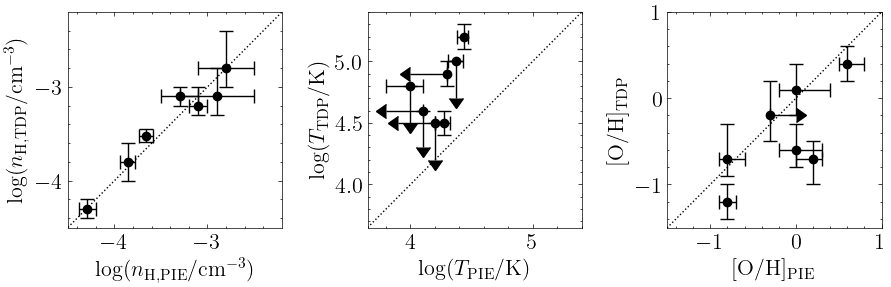

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(3.5*3, 2.8*1))

# n_H
# z=0.67

x = np.arange(-5,-2.0,0.1)
axes[0].plot(x,x,linestyle=':')

axes[0].errorbar(-2.8, -2.8, xerr=0.3, yerr=[[0.2],[0.4]], marker='o',
           linestyle='none', capsize=5, color='black')

axes[0].errorbar(-3.85, -3.8, xerr=[[0.09],[0.07]], yerr=0.2, marker='o',
           linestyle='none', capsize=5, color='black')


# z=1.09
axes[0].errorbar(-3.1, -3.2, xerr=0.1, yerr=[[0.1],[0.2]], marker='o',
           linestyle='none', capsize=5, color='black')

axes[0].errorbar(-3.66, -3.52, xerr=0.08, yerr=0.07, marker='o',
           linestyle='none', capsize=5, color='black')

# z=1.26
axes[0].errorbar(-3.3, -3.1, xerr=0.2, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='black')

# z=1.27
axes[0].errorbar(-2.9, -3.1, xerr=0.4, yerr=[[0.2],[0.3]], marker='o',
           linestyle='none', capsize=5, color='black')

axes[0].errorbar(-4.29, -4.3, xerr=0.09, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='black')

axes[0].set_xlabel(r'$\log(n_\mathrm{H,PIE}/\mathrm{cm}^{-3})$')
axes[0].set_ylabel(r'$\log(n_\mathrm{H,TDP}/\mathrm{cm}^{-3})$')

axes[0].set_xlim(-4.5, -2.2)
axes[0].set_ylim(-4.5, -2.2)

# logT

# z=0.67
axes[1].errorbar(4.27, 4.5, xerr=[[0.07],[0.05]], yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='black')

axes[1].errorbar(4.44, 5.2, xerr=[[0.06],[0.03]], yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='black')

# z=1.09
axes[1].errorbar(4.2, 4.5, xerr=0.3, yerr=0.3, marker='o', xuplims=True, uplims=True,
           linestyle='none', capsize=5, color='black')

axes[1].errorbar(4.3, 4.9, xerr=0.3, yerr=0.1, marker='o', xuplims=True, 
           linestyle='none', capsize=5, color='black')

# z=1.26
axes[1].errorbar(4.1, 4.6, xerr=0.3, yerr=0.3, marker='o', xuplims=True, uplims=True,
           linestyle='none', capsize=5, color='black')

# z=1.27
axes[1].errorbar(4.0, 4.8, xerr=[[0.2],[0.1]], yerr=0.3, marker='o', uplims=True,
           linestyle='none', capsize=5, color='black')

axes[1].errorbar(4.37, 5.0, xerr=0.06, yerr=0.3, marker='o', uplims=True,
           linestyle='none', capsize=5, color='black')

t = np.arange(3.65,5.6,0.1)
axes[1].plot(t,t,linestyle=':')

axes[1].set_xlim(3.65,5.4)
axes[1].set_ylim(3.65,5.4)

axes[1].set_xlabel(r'$\log(T_\mathrm{PIE}/\mathrm{K})$')
axes[1].set_ylabel(r'$\log(T_\mathrm{TDP}/\mathrm{K})$')

# metals

x = np.arange(-3,1.2,0.1)
axes[2].plot(x,x,linestyle=':')

# z=0.67
axes[2].errorbar(-0.8, -1.2, xerr=0.1, yerr=0.2, marker='o',
           linestyle='none', capsize=5, color='black')

axes[2].errorbar(-0.8, -0.7, xerr=[[0.1],[0.2]], yerr=[[0.2],[0.4]], marker='o',
           linestyle='none', capsize=5, color='black')

# z=1.09
axes[2].errorbar(0.2, -0.7, xerr=[[0.2],[0.1]], yerr=[[0.3],[0.2]], marker='o',
           linestyle='none', capsize=5, color='black')

axes[2].errorbar(-0.3, -0.2, xerr=0.3, yerr=[[0.3],[0.4]], marker='o', xlolims=True,
           linestyle='none', capsize=5, color='black')

# z=1.26
axes[2].errorbar(0.6, 0.4, xerr=[[0.1],[0.2]], yerr=0.2, marker='o',
           linestyle='none', capsize=5, color='black')

# z=1.27
axes[2].errorbar(0.0, -0.6, xerr=[[0.2],[0.3]], yerr=[[0.2],[0.3]], marker='o',
           linestyle='none', capsize=5, color='black')

axes[2].errorbar(0.0, 0.1, xerr=[[0.2],[0.4]], yerr=0.3, marker='o',
           linestyle='none', capsize=5, color='black')

axes[2].set_xlabel(r'$\mathrm{[O/H]_{PIE}}$')
axes[2].set_ylabel(r'$\mathrm{[O/H]_{TDP}}$')

axes[2].set_xlim(-1.5, 1.0)
axes[2].set_ylim(-1.5, 1.0)


plt.subplots_adjust(wspace=0.4, hspace=0.4)

plt.savefig(rootdir+'Figures/TDP_vs_PIE_summary_slides.pdf', dpi=300)
plt.savefig(rootdir+'Figures/TDP_vs_PIE_summary_slides.png', dpi=300)

# Extras

Plot densities versus metallicities

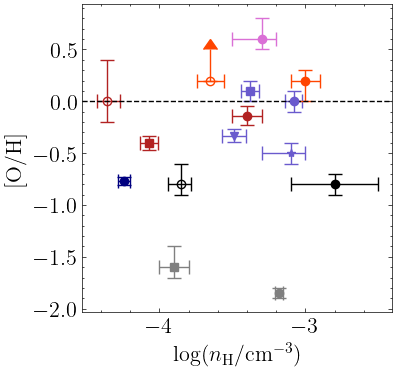

In [38]:
fig, ax = plt.subplots(1, figsize=(4,4))

# z=0.67
ax.errorbar(-2.8, -0.8, xerr = 0.3, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='black')

ax.errorbar(-3.85, -0.8, xerr = [[0.09],[0.07]], yerr=[[0.1],[0.2]], marker='o',
           linestyle='none', capsize=5, color='black', markerfacecolor='none')

# z=1.04
ax.errorbar(-3.08, 0.0, xerr = [0.06], yerr=[0.1], marker='o',
           linestyle='none', capsize=5, color='slateblue')

ax.errorbar(-3.38, 0.1, xerr = [0.06], yerr=[0.1], marker='s',
           linestyle='none', capsize=5, color='slateblue')

ax.errorbar(-3.49, -0.33, xerr = [0.08], yerr=[0.06], marker='v',
           linestyle='none', capsize=5, color='slateblue')

ax.errorbar(-3.1, -0.5, xerr = [[0.2],[0.1]], yerr=[0.1], marker='*',
           linestyle='none', capsize=5, color='slateblue')


# z=1.09
ax.errorbar(-3.0, 0.2, xerr = 0.1, yerr=[[0.2],[0.1]], marker='o',
           linestyle='none', capsize=5, color='orangered')

ax.errorbar(-3.65, 0.2, xerr = 0.09, yerr=0.3, marker='o', lolims=True,
           linestyle='none', capsize=5, color='orangered', markerfacecolor='none')

# z=1.16
ax.errorbar(-3.18, -1.85, xerr = [0.03], yerr=[0.05], marker='o',
           linestyle='none', capsize=5, color='grey')

ax.errorbar(-3.9, -1.6, xerr = [0.1], yerr=[[0.1],[0.2]], marker='s',
           linestyle='none', capsize=5, color='grey')


# z=1.22
ax.errorbar(-4.24, -0.77, xerr = [0.04], yerr=[0.04], marker='o',
           linestyle='none', capsize=5, color='navy')

# z=1.26
ax.errorbar(-3.3, 0.6, xerr = [[0.2],[0.1]], yerr=[[0.1],[0.2]], marker='o',
           linestyle='none', capsize=5, color='orchid')

# z=1.27

ax.errorbar(-3.4, -0.14, xerr = 0.1, yerr=0.09, marker='o',
           linestyle='none', capsize=5, color='firebrick')

ax.errorbar(-4.36, 0., xerr = [[0.07],[0.09]], yerr=[[0.2],[0.4]], marker='o',
           linestyle='none', capsize=5, color='firebrick', markerfacecolor='none')

ax.errorbar(-4.07, -0.40, xerr = [0.06], yerr=[0.07], marker='s',
           linestyle='none', capsize=5, color='firebrick')

ax.axhline(0, linestyle='--')
ax.set_xlabel(r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})$')
ax.set_ylabel(r'$\mathrm{[O/H]}$')

plt.savefig(rootdir+'Figures/n_H_metals.pdf', dpi=300)
plt.savefig(rootdir+'Figures/n_H_metals.png', dpi=300)

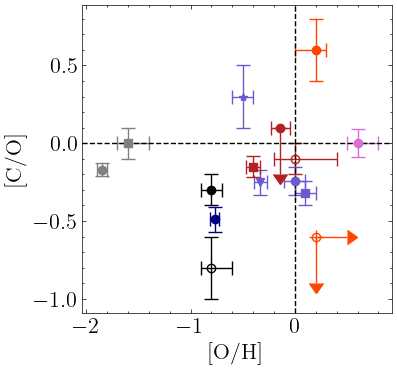

In [39]:
fig, ax = plt.subplots(1, figsize=(4,4))

# z=0.67
ax.errorbar(-0.8, -0.3, xerr = 0.1, yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='black')

ax.errorbar(-0.8, -0.8, xerr = [[0.1],[0.2]], yerr=0.2, marker='o',
           linestyle='none', capsize=5, color='black', markerfacecolor='none')


# z=1.04
ax.errorbar(0.0, -0.24, xerr = [0.1], yerr=[0.09], marker='o',
           linestyle='none', capsize=5, color='slateblue')

ax.errorbar(0.1, -0.32, xerr = [0.1], yerr=[0.08], marker='s',
           linestyle='none', capsize=5, color='slateblue')

ax.errorbar(-0.33, -0.25, xerr = [0.06], yerr=[0.08], marker='v',
           linestyle='none', capsize=5, color='slateblue')

ax.errorbar(-0.5, 0.3, xerr = [0.1], yerr=[0.2], marker='*',
           linestyle='none', capsize=5, color='slateblue')

# z=1.09

ax.errorbar(0.2, 0.6, xerr = [[0.2],[0.1]], yerr=0.2, marker='o',
           linestyle='none', capsize=5, color='orangered')

ax.errorbar(0.2, -0.6, xerr = 0.3, yerr=0.3, marker='o', xlolims=True,uplims=True,
           linestyle='none', capsize=5, color='orangered', markerfacecolor='none')

# z=1.16

ax.errorbar(-1.85, -0.17, xerr = [0.05], yerr=[0.04], marker='o',
           linestyle='none', capsize=5, color='grey')

ax.errorbar(-1.6, 0.0, xerr = [[0.1],[0.2]], yerr=[0.1], marker='s',
           linestyle='none', capsize=5, color='grey')

# z=1.22
ax.errorbar(-0.77, -0.49, xerr = [0.04], yerr=[0.08], marker='o',
           linestyle='none', capsize=5, color='navy')

# z=1.26
ax.errorbar(0.6, 0.00, xerr = [[0.1],[0.2]], yerr=[0.09], marker='o',
           linestyle='none', capsize=5, color='orchid')

# z=1.27
ax.errorbar(-0.14, 0.1, xerr = 0.09, yerr=0.3, marker='o', uplims=True,
           linestyle='none', capsize=5, color='firebrick')

ax.errorbar(0.0, -0.1, xerr = [[0.2],[0.4]], yerr=0.1, marker='o',
           linestyle='none', capsize=5, color='firebrick', markerfacecolor='none')

ax.errorbar(-0.40, -0.15, xerr = [0.07], yerr=[0.07], marker='s',
           linestyle='none', capsize=5, color='firebrick')

ax.set_xlabel(r'$\mathrm{[O/H]}$')
ax.set_ylabel(r'$\mathrm{[C/O]}$')

ax.axhline(0, linestyle='--')
ax.axvline(0, linestyle='--')

plt.savefig(rootdir+'Figures/C_O_metals.pdf', dpi=300)
plt.savefig(rootdir+'Figures/C_O_metals.png', dpi=300)

In [40]:
x = [510.19,287.42,116.62,65.60,36.76,20.72,11.66,4.75,2.67,1.50,0.85]
y = [8.39,5.74,8.80,7.78,6.97,6.35,5.90,7.73,7.56,7.51,7.53]

x1 = [367.59,207.25,84.61,47.53,26.71,10.96,6.15,3.45,0.62,1.10,0.62]
y1 = [2.97,2.72,3.37,2.96,2.62,3.29,3.18,3.55,11.44,6.33,3.64]

x2 = [367.59,150.21,84.61,34.54,19.49,10.96,6.15,3.45,0.62,1.10,0.62]
y2 = [1.15,1.46,1.18,1.18,1.11,1.10,1.12,1.15,3.71,1.19,1.18]

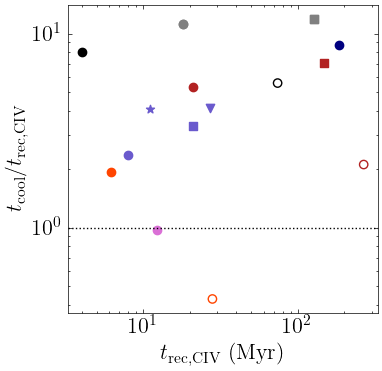

In [41]:
fig, ax = plt.subplots(1, figsize=(4,4))

# z=0.67
ax.scatter(4, 32/4, marker='o', color='black')
ax.scatter(74, 411/74, marker='o', color='black', facecolor='none')

# z=1.04
ax.scatter(8, 19/8, marker='o', color='slateblue')
ax.scatter(21, 70/21, marker='s', color='slateblue')
ax.scatter(27, 111/27, marker='v', color='slateblue')
ax.scatter(11, 45/11, marker='*', color='slateblue')

# z=1.09
ax.scatter(6.2, 12/6.2, marker='o', color='orangered')
ax.scatter(28, 12/28, marker='o', color='orangered', facecolor='none')

# z=1.16
ax.scatter(18, 201/18, marker='o', color='grey')
ax.scatter(128, 1521/128, marker='s', color='grey')

# z=1.16
ax.scatter(18, 201/18, marker='o', color='grey')
ax.scatter(128, 1521/128, marker='s', color='grey')

# z=1.22
ax.scatter(185, 1607/185, marker='o', color='navy')

# z=1.26
ax.scatter(12.3, 12.0/12.3, marker='o', color='orchid')
#ax.scatter(11, 67/11, marker='o', color='orchid')

# z=1.27
ax.scatter(21, 111/21, marker='o', color='firebrick')
ax.scatter(267, 564/267, marker='o', color='firebrick', facecolor='none')

ax.scatter(147, 1033/147, marker='s', color='firebrick')

ax.axhline(1, linestyle=':')

ax.set_xlabel(r'$t_\mathrm{rec,CIV} \ (\mathrm{Myr})$')
ax.set_ylabel(r'$t_\mathrm{cool}/t_\mathrm{rec,CIV}$')

ax.set_xscale('log')
ax.set_yscale('log')

#ax.plot(x,y, linestyle='--', label=r'$Z=0.1Z_\odot$')
#ax.plot(x1,y1, linestyle='-.', label=r'$Z=Z_\odot$', color='black')
#ax.plot(x2,y2, linestyle=':', lw=1.5, label=r'$Z=3Z_\odot$', color='black')

#ax.set_xlim(1.1e0,3e2)
#ax.legend(fontsize=8, loc='center left')
plt.savefig(rootdir+'Figures/t_rec_t_cool.pdf', dpi=300)
plt.savefig(rootdir+'Figures/t_rec_t_cool.png', dpi=300)

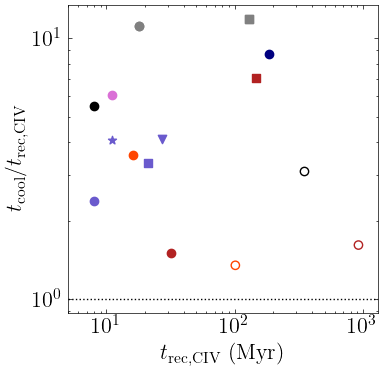

In [42]:
fig, ax = plt.subplots(1, figsize=(4,4))

# z=0.67
ax.scatter(8, 44/8, marker='o', color='black')
ax.scatter(349, 1077/349, marker='o', color='black', facecolor='none')

# z=1.04
ax.scatter(8, 19/8, marker='o', color='slateblue')
ax.scatter(21, 70/21, marker='s', color='slateblue')
ax.scatter(27, 111/27, marker='v', color='slateblue')
ax.scatter(11, 45/11, marker='*', color='slateblue')

# z=1.09
ax.scatter(16, 57/16, marker='o', color='orangered')
ax.scatter(101, 136/101, marker='o', color='orangered', facecolor='none')

# z=1.16
ax.scatter(18, 201/18, marker='o', color='grey')
ax.scatter(128, 1521/128, marker='s', color='grey')

# z=1.16
ax.scatter(18, 201/18, marker='o', color='grey')
ax.scatter(128, 1521/128, marker='s', color='grey')

# z=1.22
ax.scatter(185, 1607/185, marker='o', color='navy')

# z=1.26
ax.scatter(11, 67/11, marker='o', color='orchid')

# z=1.27
ax.scatter(32, 48/32, marker='o', color='firebrick')
ax.scatter(919, 1480/919, marker='o', color='firebrick', facecolor='none')

ax.scatter(147, 1033/147, marker='s', color='firebrick')

ax.axhline(1, linestyle=':')

ax.set_xlabel(r'$t_\mathrm{rec,CIV} \ (\mathrm{Myr})$')
ax.set_ylabel(r'$t_\mathrm{cool}/t_\mathrm{rec,CIV}$')

ax.set_xlim(5, 1.3e3)
ax.set_xscale('log')
ax.set_yscale('log')

plt.savefig(rootdir+'Figures/t_rec_t_cool_TDP.pdf', dpi=300)
plt.savefig(rootdir+'Figures/t_rec_t_cool_TDP.png', dpi=300)